Found 711 images belonging to 6 classes.
Found 174 images belonging to 6 classes.


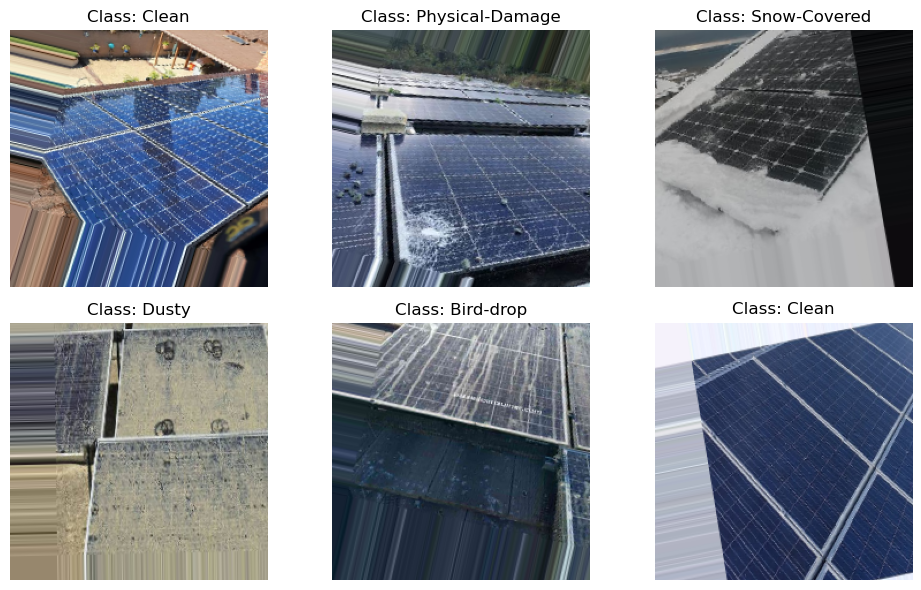

In [21]:

# Step 1: Data Preprocessing 


import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt


# 1. Define Paths

DATA_DIR = "Faulty_solar_panel"  
IMG_SIZE = (224, 224)            
BATCH_SIZE = 32                  


# 2. Data Augmentation


train_datagen = ImageDataGenerator(
    rescale=1.0/255,            
    rotation_range=20,          
    width_shift_range=0.2,      
    height_shift_range=0.2,     
    shear_range=0.2,            
    zoom_range=0.2,             
    horizontal_flip=True,       
    fill_mode='nearest',        
    validation_split=0.2        


val_datagen = ImageDataGenerator(
    rescale=1.0/255,
    validation_split=0.2
)


# 3. Load Train and Validation Sets

train_gen = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)


x_batch, y_batch = next(train_gen)
plt.figure(figsize=(10, 6))

for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(x_batch[i])
    plt.title(f"Class: {list(train_gen.class_indices.keys())[y_batch[i].argmax()]}")
    plt.axis("off")

plt.tight_layout()
plt.show()



Found 885 images belonging to 6 classes.


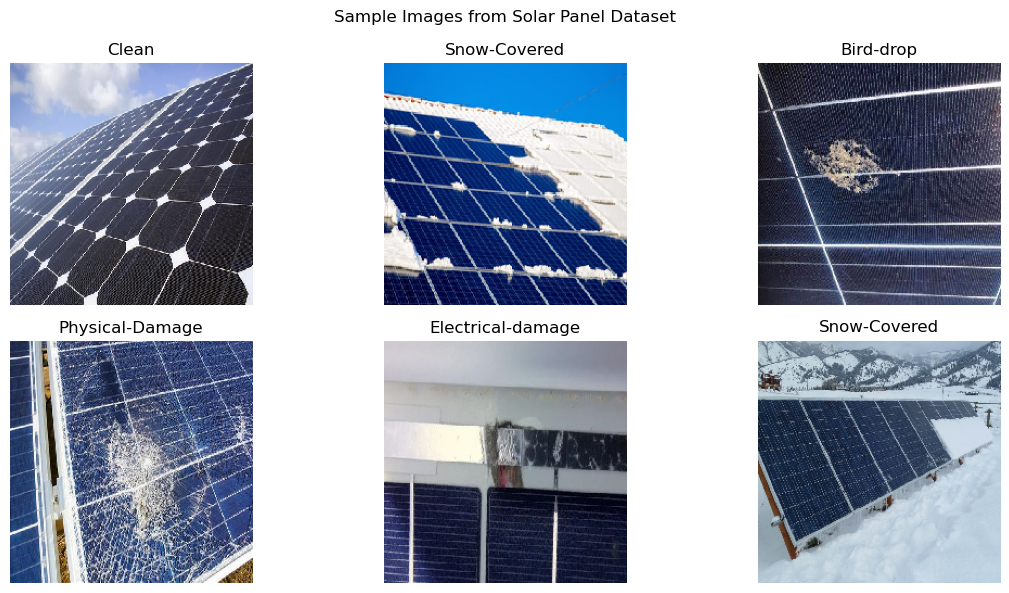

C:\Users\S.HARSHINI\AppData\Local\Temp\ipykernel_15844\939452868.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), palette="viridis")


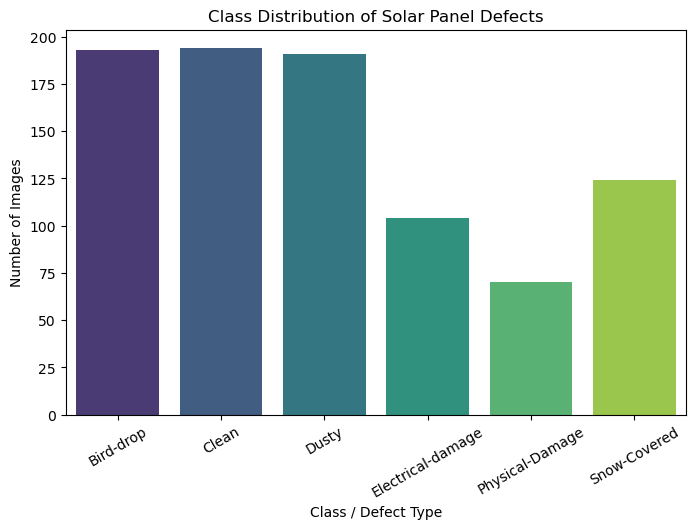

=== Defect Pattern Insights ===
Class 'Bird-drop': 193 images (22.0%) → dominant defect type
Class 'Clean': 194 images (22.1%) → dominant defect type
Class 'Dusty': 191 images (21.8%) → dominant defect type
Class 'Electrical-damage': 104 images (11.9%) → rare defect type
Class 'Physical-Damage': 70 images (8.0%) → rare defect type
Class 'Snow-Covered': 124 images (14.2%) → rare defect type


In [24]:

# Visual Inspection & Defect Pattern Insights 


import os
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator


# Paths 

DATA_DIR = "Faulty_solar_panel"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32


datagen = ImageDataGenerator(rescale=1./255)
gen = datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)


# 2. Sample Images

x_batch, y_batch = next(gen)
plt.figure(figsize=(12, 6))
for i in range(6):  # Display 6 sample images
    plt.subplot(2, 3, i+1)
    plt.imshow(x_batch[i])
    label = list(gen.class_indices.keys())[y_batch[i].argmax()]
    plt.title(label)
    plt.axis("off")
plt.suptitle("Sample Images from Solar Panel Dataset")
plt.tight_layout()
plt.show()


# 3. Class Distribution

class_counts = {cls: len(os.listdir(os.path.join(DATA_DIR, cls))) 
                for cls in os.listdir(DATA_DIR)}

# Bar plot of class counts
plt.figure(figsize=(8, 5))
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), palette="viridis")
plt.title("Class Distribution of Solar Panel Defects")
plt.xlabel("Class / Defect Type")
plt.ylabel("Number of Images")
plt.xticks(rotation=30)
plt.show()


# 4. Automatic Insights

total_images = sum(class_counts.values())
print("=== Defect Pattern Insights ===")
for cls, count in class_counts.items():
    percent = (count / total_images) * 100
    status = "dominant" if percent > 20 else "rare"
    print(f"Class '{cls}': {count} images ({percent:.1f}%) → {status} defect type")


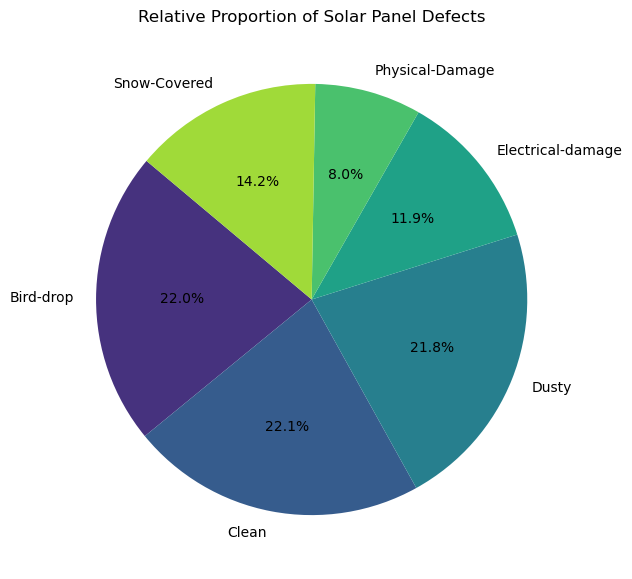

In [28]:
import numpy as np


# Pie Chart: Overall Share of Classes

plt.figure(figsize=(7, 7))
plt.pie(class_counts.values(), labels=class_counts.keys(),
        autopct='%1.1f%%', startangle=140, colors=sns.color_palette("viridis", len(class_counts)))
plt.title("Relative Proportion of Solar Panel Defects")
plt.show()

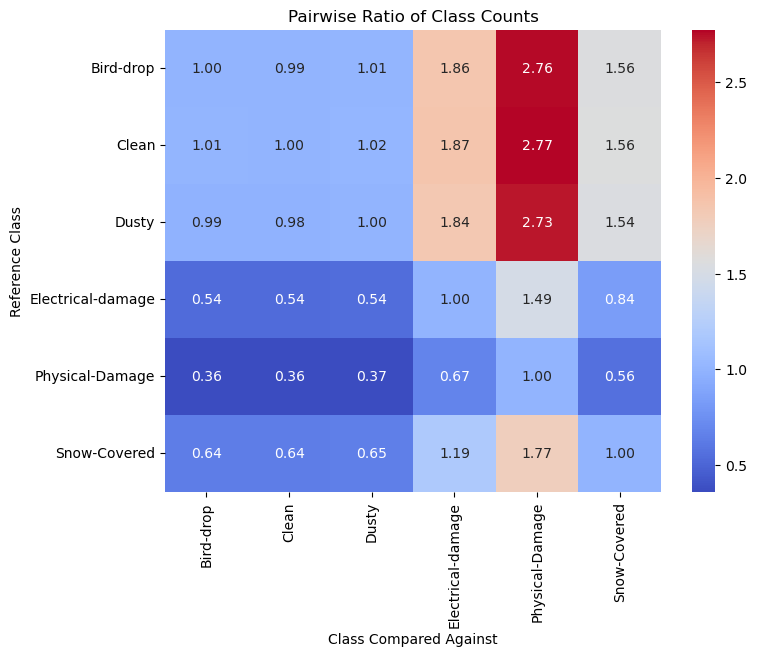

In [29]:
# Heatmap

classes = list(class_counts.keys())
n = len(classes)
ratio_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        ratio_matrix[i, j] = class_counts[classes[i]] / class_counts[classes[j]]

plt.figure(figsize=(8, 6))
sns.heatmap(ratio_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            xticklabels=classes, yticklabels=classes)
plt.title("Pairwise Ratio of Class Counts")
plt.xlabel("Class Compared Against")
plt.ylabel("Reference Class")
plt.show()

C:\Users\S.HARSHINI\AppData\Local\Temp\ipykernel_15844\1837406191.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(normalized_counts.keys()), y=list(normalized_counts.values()), palette="magma")


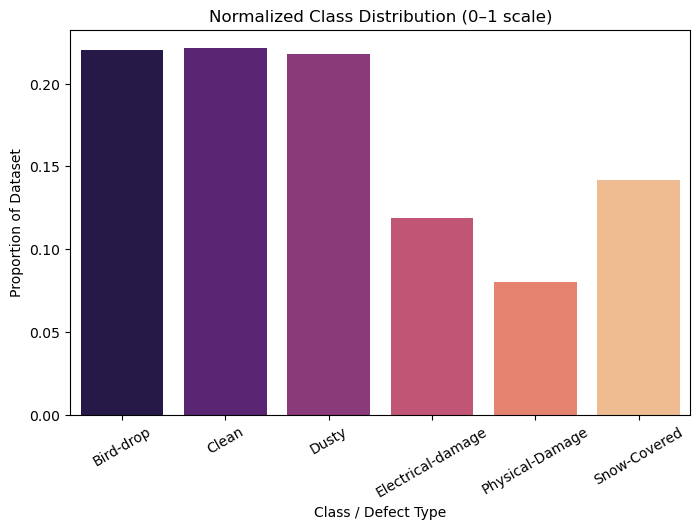

In [30]:
# Normalized Class Distribution

normalized_counts = {cls: count/total_images for cls, count in class_counts.items()}

plt.figure(figsize=(8, 5))
sns.barplot(x=list(normalized_counts.keys()), y=list(normalized_counts.values()), palette="magma")
plt.title("Normalized Class Distribution (0–1 scale)")
plt.xlabel("Class / Defect Type")
plt.ylabel("Proportion of Dataset")
plt.xticks(rotation=30)
plt.show()



 Defect Insight
Most frequent defect: 'Clean' with 194 images (22.15% of dataset).
 Rarest defect: 'Physical-Damage' with 70 images (7.99% of dataset).


C:\Users\S.HARSHINI\AppData\Local\Temp\ipykernel_15844\2265629995.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(sorted_counts.keys()), y=list(sorted_counts.values()), palette="coolwarm")


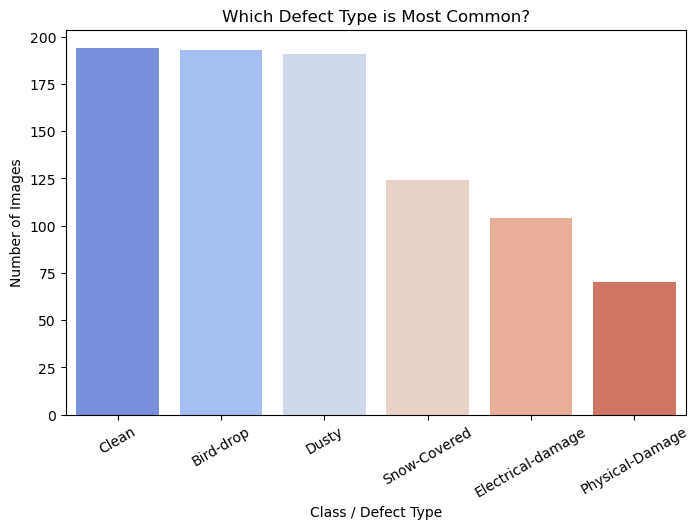

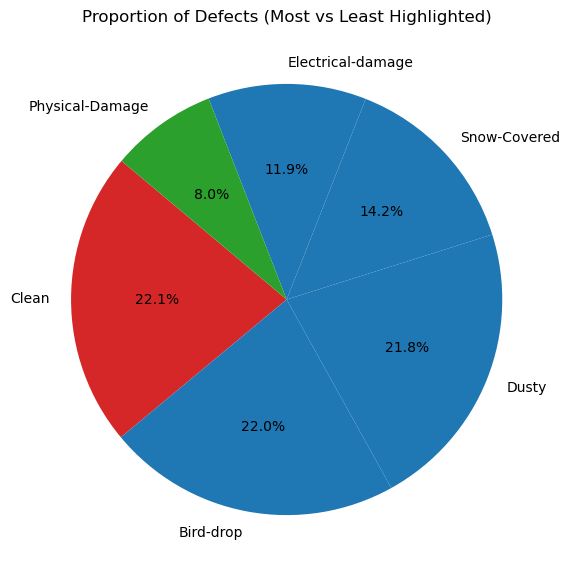

In [31]:

# Which Class Has More Defects?

max_class = max(class_counts, key=class_counts.get)
max_count = class_counts[max_class]

min_class = min(class_counts, key=class_counts.get)
min_count = class_counts[min_class]

print("\n Defect Insight")
print(f"Most frequent defect: '{max_class}' with {max_count} images "
      f"({(max_count/total_images)*100:.2f}% of dataset).")
print(f" Rarest defect: '{min_class}' with {min_count} images "
      f"({(min_count/total_images)*100:.2f}% of dataset).")

sorted_counts = dict(sorted(class_counts.items(), key=lambda x: x[1], reverse=True))

plt.figure(figsize=(8, 5))
sns.barplot(x=list(sorted_counts.keys()), y=list(sorted_counts.values()), palette="coolwarm")
plt.title("Which Defect Type is Most Common?")
plt.xlabel("Class / Defect Type")
plt.ylabel("Number of Images")
plt.xticks(rotation=30)
plt.show()

colors = ["#d62728" if cls == max_class else "#2ca02c" if cls == min_class else "#1f77b4"
          for cls in sorted_counts.keys()]

plt.figure(figsize=(7, 7))
plt.pie(sorted_counts.values(), labels=sorted_counts.keys(), autopct='%1.1f%%',
        startangle=140, colors=colors)
plt.title("Proportion of Defects (Most vs Least Highlighted)")
plt.show()


Class Weights: {0: np.float64(0.713855421686747), 1: np.float64(0.7645161290322581), 2: np.float64(0.7796052631578947), 3: np.float64(1.427710843373494), 4: np.float64(2.1160714285714284), 5: np.float64(1.196969696969697)}


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_pad (ZeroPadding2D)     │ (None, 230, 230, 3)       │               0 │ input_layer_9[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_conv (Conv2D)           │ (None, 112, 112, 64)      │           9,472 │ conv1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_bn (BatchNormalization) │ (None, 112, 112, 64)      │             256 │ conv1_conv[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_relu (Activation)       │ (None, 112, 112, 64)      │               0 │ conv1_bn[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pad (ZeroPadding2D)     │ (None, 114, 114, 64)      │               0 │ conv1_relu[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pool (MaxPooling2D)     │ (None, 56, 56, 64)        │               0 │ pool1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_conv (Conv2D)  │ (None, 56, 56, 64)        │           4,160 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_bn             │ (None, 56, 56, 64)        │             256 │ conv2_block1_1_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_1_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_conv (Conv2D)  │ (None, 56, 56, 64)        │          36,928 │ conv2_block1_1_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_bn             │ (None, 56, 56, 64)        │             256 │ conv2_block1_2_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_2_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_0_conv (Conv2D)  │ (None, 56, 56, 256)       │          16,640 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_3_conv (Conv2D)  │ (None, 56, 56, 256)       │          16,640 │ conv2_block1_2_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 23,600,006 (90.03 MB)

 Trainable params: 8,943,622 (34.12 MB)

 Non-trainable params: 14,656,384 (55.91 MB)

Epoch 1/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 130s 5s/step - accuracy: 0.2968 - loss: 1.6774 - val_accuracy: 0.1724 - val_loss: 1.9345
Epoch 2/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 100s 4s/step - accuracy: 0.4163 - loss: 1.4912 - val_accuracy: 0.0805 - val_loss: 1.9536
Epoch 3/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 99s 4s/step - accuracy: 0.4374 - loss: 1.4562 - val_accuracy: 0.1149 - val_loss: 1.9057
Epoch 4/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 143s 4s/step - accuracy: 0.4093 - loss: 1.3885 - val_accuracy: 0.1149 - val_loss: 1.9074
Epoch 5/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 142s 4s/step - accuracy: 0.4754 - loss: 1.3685 - val_accuracy: 0.2184 - val_loss: 1.7608
Epoch 6/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 141s 4s/step - accuracy: 0.4754 - loss: 1.3126 - val_accuracy: 0.2874 - val_loss: 1.6888
Epoch 7/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 1651s 4s/step - accuracy: 0.4768 - loss: 1.3063 - val_accuracy: 0.2989 - val_loss: 1.6487
Epoch 8/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 279s 11s/step - accuracy: 0.4880 - loss: 1.3329 - val_accuracy: 0.3161 - 

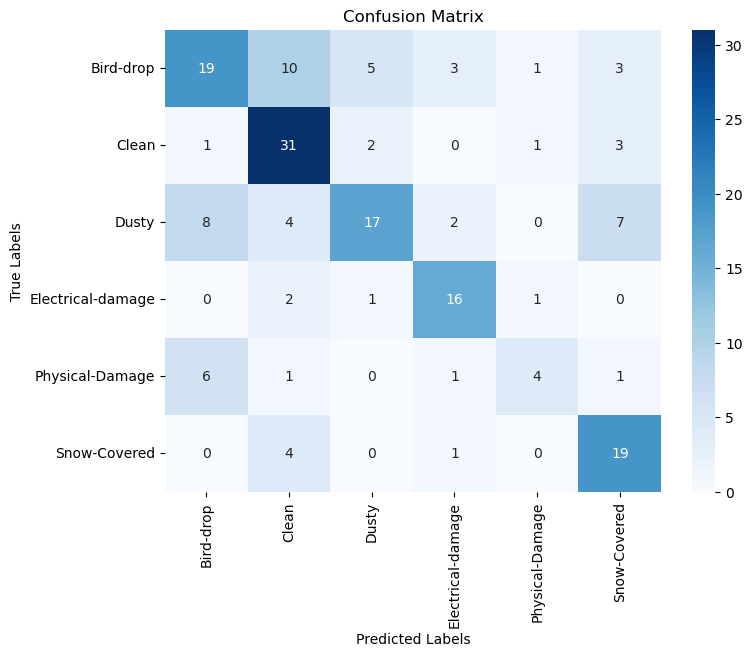

In [27]:

# CNN 

import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



num_classes = len(train_gen.class_indices)


y_train_labels = train_gen.classes
class_weights_values = compute_class_weight(class_weight='balanced',
                                            classes=np.unique(y_train_labels),
                                            y=y_train_labels)
class_weights = dict(enumerate(class_weights_values))
print("Class Weights:", class_weights)


# ResNet50 

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = True


for layer in base_model.layers[:-20]:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
predictions = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    class_weight=class_weights,
    callbacks=[early_stop]
)


# Evaluate Model

val_gen.reset()
y_pred_prob = model.predict(val_gen)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = val_gen.classes

print("Classification Report")
print(classification_report(y_true, y_pred, target_names=list(train_gen.class_indices.keys())))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=list(train_gen.class_indices.keys()),
            yticklabels=list(train_gen.class_indices.keys()))
plt.ylabel("True Labels")
plt.xlabel("Predicted Labels")
plt.title("Confusion Matrix")
plt.show()


In [32]:
# Save Model 
model.save("solar_model.h5")
print("Model saved as solar_model.h5")


Model saved as solar_model.h5
